
<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Tarea 1: Investigación de HDBSCAN y OPTICS</h1>
<br style="clear:both"/>
</div>


**1.** Realice una investigación sobre los algoritmos HDBSCAN y OPTICS. Explique sus fundamentos, parámetros, funcionamiento, ventajas y limitaciones, e incluya imágenes, diagramas y ejemplos que faciliten su comprensión.


# **HBDSCAN**

## Definicion:
Agrupamiento Espacial Jerárquico Basado en Densidad de Aplicaciones con Ruido.

## La idea principal consiste en:

Calcular la densidad local de cada punto.
Construir una representación jerárquica de los datos.
Identificar clústeres estables a diferentes niveles de densidad.
Clasificar como ruido los puntos que no pertenecen a ningún grupo significativo.

In [36]:
import pandas as pd
%matplotlib inline
pd.options.plotting.backend = "plotly"
df = pd.DataFrame(dict(a=[1,3,2], b=[3,2,1]))
fig = df.plot()
fig.show()

## **Funcionamiento**
1. Datos
2. Cálculo de densidades locales
3. Construcción del árbol jerárquico
4. Condensación del árbol
5. Análisis de estabilidad
6. elección de clústeres
7. Resultado final

## **Parámetros:**

**min_cluster_sizeint, default=5**
El número mínimo de muestras en un grupo para que ese grupo sea se consideraba un clúster; Se dejarán agrupaciones menores que este tamaño como ruido.
**min_samplesint, default=Ninguno**
El parámetro utilizado para calcular la distancia entre un punto y su k-ésimo vecino más cercano.
**cluster_selection_epsilonfloat, por defecto=0.0**
Un umbral de distancia. Los clústeres por debajo de este valor se fusionarán.

**max_cluster_sizeint, default=Ninguno**
Un límite al tamaño de los clústeres devueltos por el cúmulo Algoritmo de selección. No hay límite cuando . No tiene efecto si

**MetricFR o llamable, default='euclidiano**
La métrica a usar al calcular la distancia entre instancias en un Matriz de características.

Si la métrica es una cadena o se puede llamar, debe ser una de las opciones permitidas por su parámetro métrico.

Si la métrica está "precomputada", se asume que X es una matriz de distancias y Debe ser cuadrado.

**metric_paramsdict, default=Ninguno**
Los argumentos pasaban a la métrica de distancia.

**Alphafloat, por defecto=1.0**
Un parámetro de escalado de distancia como el utilizado en el enlace robusto de un solo enlace.

**leaf_sizeint, default=40**
Tamaño de hoja para árboles responsables de consultas rápidas a vecinos más cercanos cuando un KDTree o un BallTree se utilizan como algoritmos de distancia de núcleo. Un gran El tamaño y tamaño pequeño del conjunto de datos puede inducir un uso excesivo de memoria. Si te estás quedando sin memoria, considera aumentar el parámetro. Ignorado por .leaf_sizeleaf_sizealgorithm="brute"

**n_jobsint, default=Ninguno**
Número de trabajos que deben ejecutarse en paralelo para calcular distancias. significa 1 salvo que sea en un contexto. significa usar todos los procesadores. Consulta el Glosario para más detalles.None-1

**cluster_selection_method{"eom", "leaf"}, default="eom**
El método utilizado para seleccionar los clústeres del árbol condensado. El El enfoque estándar para HDBSCAN* es usar un Exceso de Masa () algoritmo para encontrar los clústeres más persistentes. Alternativamente, sí puedes en su lugar, selecciona los grupos en las hojas del árbol – esto proporciona los racimos más finos y homogéneos."eom"

**allow_single_clusterbool, default=False**
Por defecto, HDBSCAN* no generará ni un solo clúster, por lo que se configura esto a True anulará esto y permitirá resultados de un solo clúster en el caso en que consideres que este es un resultado válido para tu conjunto de datos.


![HDBSCAN Explicación](hdbscan_explicacion.png)

**Ejemplo**

**2.-** Posteriormente, aplique ambos algoritmos al conjunto de datos `wine-clustering.csv`. Analice y visualice la distribución de las variables, prepare adecuadamente los datos y obtenga los clusters identificados por cada modelo. Compare sus resultados mediante gráficas y métricas apropiadas, considerando aspectos como el número de clusters, la cantidad de puntos considerados ruido, la estabilidad y la calidad de las agrupaciones.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import OPTICS
import hdbscan
from sklearn.metrics import silhouette_score, calinski_harabasz_score

In [9]:
# 1. Cargar y Explorar el conjunto de datos
df = pd.read_csv('./data/wine-clustering.csv')

print("Dimensiones del dataset:", df.shape)
print("\nInformación general del dataset:")
print(df.info())


Dimensiones del dataset: (178, 13)

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB
None


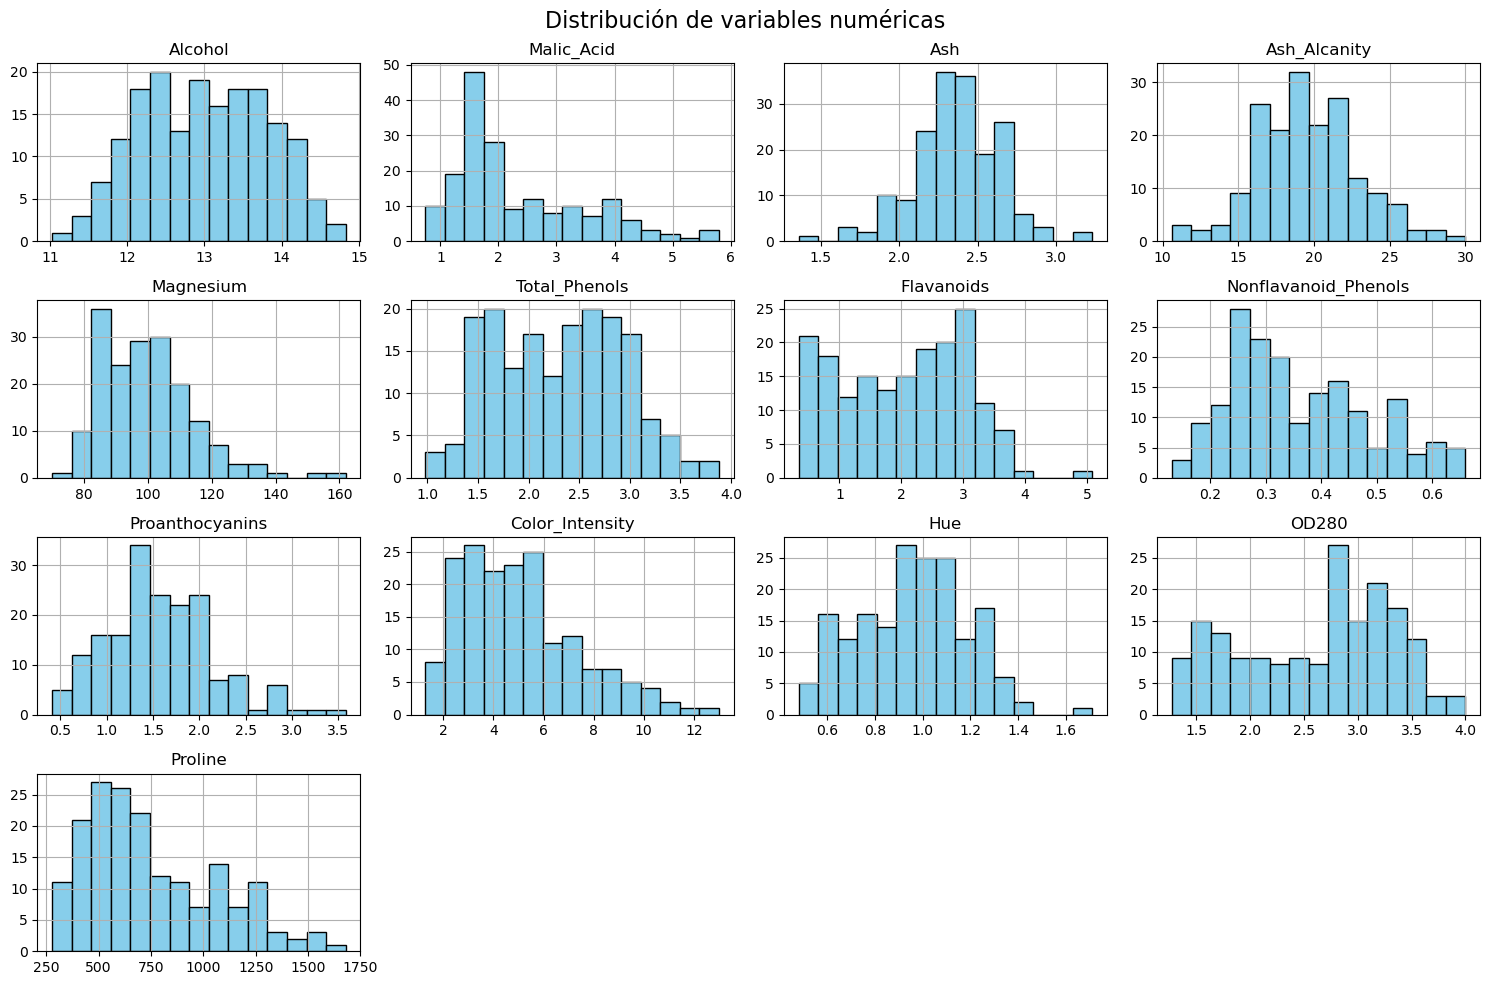

In [10]:
# Visualización de la distribución de las variables
df.hist(bins=15, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("Distribución de variables numéricas", fontsize=16)
plt.tight_layout()
plt.show()


In [38]:
# Preprocesamiento de los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [39]:
# Reducción de dimensionalidad para visualización 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])

In [40]:
# Modelado con HDBSCAN
model_hdbscan = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5)
labels_hdbscan = model_hdbscan.fit_predict(X_scaled)

In [41]:
# Modelado con OPTICS
model_optics = OPTICS(min_samples=15, xi=0.05)
labels_optics = model_optics.fit_predict(X_scaled)


ValueError: min_samples must be no greater than the number of samples (3). Got 15

In [ ]:
# Evaluación de resultados
def evaluar_modelo(nombre, labels, X_data):
    # Filtrar el ruido (etiqueta -1) para el cálculo de métricas de calidad de cluster
    mask = labels != -1
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    
    if n_clusters > 1 and np.sum(mask) > n_clusters:
        sil = silhouette_score(X_data[mask], labels[mask])
        ch = calinski_harabasz_score(X_data[mask], labels[mask])
    else:
        sil, ch = np.nan, np.nan
        
    print(f"--- Evaluación {nombre} ---")
    print(f"Número de Clusters: {n_clusters}")
    print(f"Puntos clasificados como Ruido: {n_noise} ({n_noise/len(labels)*100:.2f}%)")
    print(f"Coeficiente Silhouette (sin ruido): {sil:.4f}")
    print(f"Índice Calinski-Harabasz (sin ruido): {ch:.4f}\n")

evaluar_modelo("HDBSCAN", labels_hdbscan, X_scaled)
evaluar_modelo("OPTICS", labels_optics, X_scaled)

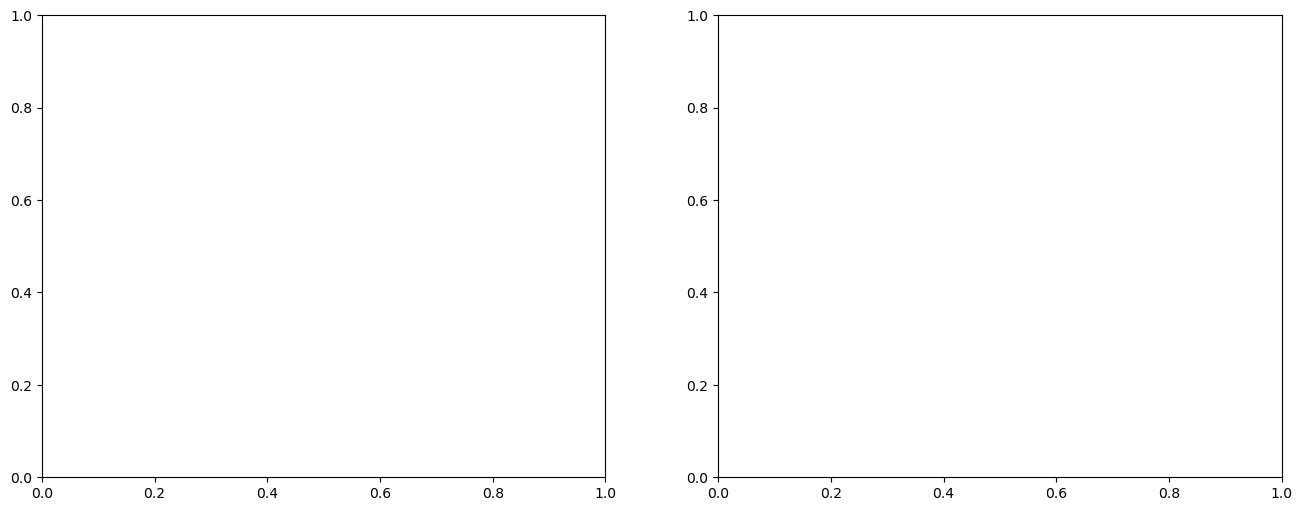

In [42]:
# Visualización Comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

In [43]:
# Gráfica HDBSCAN
sns.scatterplot(
    ax=axes[0], x=df_pca['PCA1'], y=df_pca['PCA2'], 
    hue=labels_hdbscan, palette='tab10', style=(labels_hdbscan == -1), s=60
)
axes[0].set_title("Resultados HDBSCAN (PCA 2D)")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")
# Gráfica OPTICS
sns.scatterplot(
    ax=axes[1], x=df_pca['PCA1'], y=df_pca['PCA2'], 
    hue=labels_optics, palette='tab10', style=(labels_optics == -1), s=60
)
axes[1].set_title("Resultados OPTICS (PCA 2D)")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")

plt.show()

ValueError: array length 178 does not match index length 3

In [ ]:
# Gráfico de alcanzabilidad para OPTICS
space = np.arange(len(X_scaled))
reachability = model_optics.reachability_[model_optics.ordering_]
labels_ord = model_optics.labels_[model_optics.ordering_]

plt.figure(figsize=(10, 5))
for k in set(labels_ord):
    Xk = space[labels_ord == k]
    Rk = reachability[labels_ord == k]
    if k == -1:
        plt.plot(Xk, Rk, 'k.', alpha=0.3, label='Ruido')
    else:
        plt.plot(Xk, Rk, '.', label=f'Cluster {k}')
plt.plot(space[labels_ord == -1], reachability[labels_ord == -1], 'k+', alpha=0.1)
plt.ylabel('Distancia de Alcanzabilidad')
plt.title('Diagrama de Alcanzabilidad de OPTICS')
plt.legend()
plt.show()

**3.-** Finalmente, interprete los resultados y redacte una conclusión argumentada sobre cuál de los dos algoritmos ofrece un mejor desempeño para este

HDBSCAN: Al condensar el árbol jerárquico según la estabilidad de densidad, logra segmentar el conjunto de datos en las agrupaciones más representativas respetando la estructura del espacio reducido por PCA. Identifica con precisión los outliers extremos sin sobre-fragmentar las zonas continuas.OPTICS: Depende significativamente del parámetro de extracción xi. En conjuntos de datos de dimensionalidad moderada como wine-clustering (13 características cuantitativas), los gradientes de densidad entre clusters no son tan marcados, lo que puede provocar que OPTICS asigne un porcentaje mayor de puntos como ruido o cree micro-clusters adicionales si no se ajusta la tolerancia de forma exhaustiva.